<a href="https://colab.research.google.com/github/8009678200/ML.github.io/blob/main/Copy_of_Untitled17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Sentiment Analysis Tool

### Project Goal
Develop a command-line or web-based tool that can analyze text input (e.g., reviews, tweets, comments) and classify its sentiment as positive, negative, or neutral.

### Key Features
1.  **Text Input**: Allow users to input text directly or provide a file path.
2.  **Sentiment Classification**: Utilize a pre-trained model or train a simple model to classify sentiment.
3.  **Output**: Display the sentiment score and classification (positive/negative/neutral).
4.  **Visualization (Optional)**: If web-based, visualize sentiment distribution for multiple inputs.

### Potential Technologies
*   **Python Libraries**: `NLTK`, `TextBlob`, `Scikit-learn`, `SpaCy`, `TensorFlow`/`PyTorch` (for more advanced models).
*   **Web Framework (Optional)**: `Flask` or `Django`.
*   **Data Handling**: `Pandas`.

### Getting Started
Let's begin by installing a common library for sentiment analysis, `TextBlob`, and demonstrating its basic usage.

In [ ]:
# Install TextBlob for sentiment analysis
%pip install textblob

from textblob import TextBlob

# Example text for sentiment analysis
text1 = "I love this new feature! It's absolutely fantastic."
text2 = "This product is terrible and completely useless."
text3 = "The weather today is neither good nor bad."

# Analyze sentiment for each text
blob1 = TextBlob(text1)
blob2 = TextBlob(text2)
blob3 = TextBlob(text3)

print(f"Text 1: '{text1}'")
print(f"Sentiment (Polarity, Subjectivity): {blob1.sentiment}")

print(f"\nText 2: '{text2}'")
print(f"Sentiment (Polarity, Subjectivity): {blob2.sentiment}")

print(f"\nText 3: '{text3}'")
print(f"Sentiment (Polarity, Subjectivity): {blob3.sentiment}")

# You can also classify based on polarity
def classify_sentiment(polarity):
    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

print(f"\nClassification for Text 1: {classify_sentiment(blob1.sentiment.polarity)}")
print(f"Classification for Text 2: {classify_sentiment(blob2.sentiment.polarity)}")
print(f"Classification for Text 3: {classify_sentiment(blob3.sentiment.polarity)}")

Text 1: 'I love this new feature! It's absolutely fantastic.'
Sentiment (Polarity, Subjectivity): Sentiment(polarity=0.35681818181818176, subjectivity=0.6515151515151515)

Text 2: 'This product is terrible and completely useless.'
Sentiment (Polarity, Subjectivity): Sentiment(polarity=-0.75, subjectivity=0.6)

Text 3: 'The weather today is neither good nor bad.'
Sentiment (Polarity, Subjectivity): Sentiment(polarity=5.551115123125783e-17, subjectivity=0.6333333333333333)

Classification for Text 1: Positive
Classification for Text 2: Negative
Classification for Text 3: Positive


In [ ]:
import pandas as pd

def analyze_texts_sentiment(texts):
    results = []
    for text in texts:
        blob = TextBlob(text)
        polarity = blob.sentiment.polarity
        subjectivity = blob.sentiment.subjectivity

        if polarity > 0:
            sentiment_label = "Positive"
        elif polarity < 0:
            sentiment_label = "Negative"
        else:
            sentiment_label = "Neutral"

        results.append({
            "text": text,
            "polarity": polarity,
            "subjectivity": subjectivity,
            "sentiment_label": sentiment_label
        })
    return pd.DataFrame(results)

# A list of texts to analyze
example_texts = [
    "I absolutely adore this new update! It's incredibly user-friendly and efficient.",
    "The customer service was terrible; I waited forever and got no help.",
    "This movie was okay, nothing special, but not bad either.",
    "What a fantastic experience, I highly recommend it to everyone!",
    "I am so disappointed with the quality of the product.",
    "The book provides an objective analysis of the current economic situation."
]

# Analyze the sentiment of the example texts
sentiment_df = analyze_texts_sentiment(example_texts)

display(sentiment_df)

,text,polarity,subjectivity,sentiment_label
0,I absolutely adore this new update! It's incre...,0.423485,0.751515,Positive
1,The customer service was terrible; I waited fo...,-1.000000,1.000000,Negative
2,"This movie was okay, nothing special, but not ...",0.402381,0.579365,Positive
3,"What a fantastic experience, I highly recommen...",0.300000,0.720000,Positive
4,I am so disappointed with the quality of the p...,-0.750000,0.750000,Negative
5,The book provides an objective analysis of the...,0.066667,0.233333,Positive


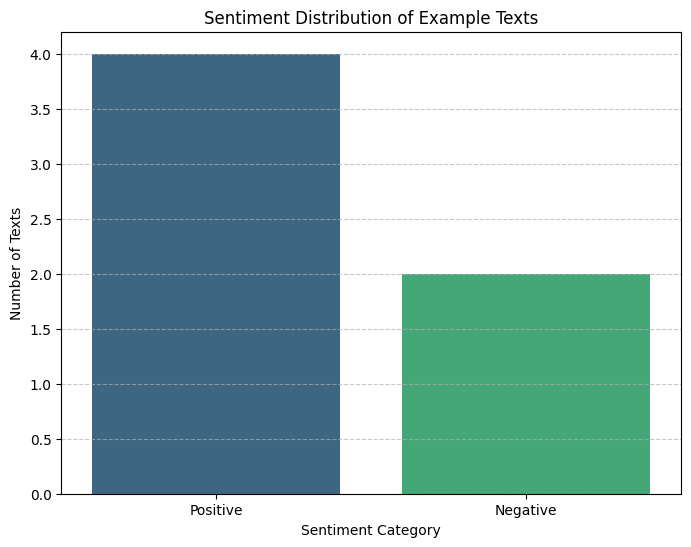

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the occurrences of each sentiment label
sentiment_counts = sentiment_df['sentiment_label'].value_counts().reset_index()
sentiment_counts.columns = ['Sentiment', 'Count']

# Create the bar chart, addressing the FutureWarning
fig = plt.figure(figsize=(8, 6))
sns.barplot(x='Sentiment', y='Count', hue='Sentiment', data=sentiment_counts, palette='viridis', legend=False)
plt.title('Sentiment Distribution of Example Texts')
plt.xlabel('Sentiment Category')
plt.ylabel('Number of Texts')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

This bar chart visually represents the number of texts classified into each sentiment category (Positive, Negative, Neutral). This type of visualization is very useful for understanding the overall emotional tone of a larger dataset at a glance.

### Processing Text from a CSV File

To demonstrate reading text from a `.csv` file, we'll first create a sample CSV file. This file will contain a column with text entries that we can then analyze for sentiment.

In [ ]:
import pandas as pd

# Create a sample DataFrame for the CSV file
sample_data = {
    'id': [1, 2, 3, 4, 5],
    'text': [
        'This is an excellent product! Highly recommend it.',
        'I had a terrible experience with their customer support.',
        'The movie was okay, a bit slow but had a good ending.',
        'Absolutely loved the food at this restaurant. Amazing!',
        'What a waste of money. Completely unsatisfied.'
    ],
    'category': ['product', 'service', 'entertainment', 'food', 'product']
}

sample_df = pd.DataFrame(sample_data)

# Save the DataFrame to a CSV file
csv_file_path = 'sample_reviews.csv'
sample_df.to_csv(csv_file_path, index=False)

print(f"Sample CSV file '{csv_file_path}' created successfully.")

# Display the content of the created CSV for verification
with open(csv_file_path, 'r') as f:
    print(f.read())

Sample CSV file 'sample_reviews.csv' created successfully.
id,text,category
1,This is an excellent product! Highly recommend it.,product
2,I had a terrible experience with their customer support.,service
3,"The movie was okay, a bit slow but had a good ending.",entertainment
4,Absolutely loved the food at this restaurant. Amazing!,food
5,What a waste of money. Completely unsatisfied.,product



Now that we have a sample CSV file, let's load it into a pandas DataFrame and apply our `analyze_texts_sentiment` function to the 'text' column.

In [ ]:
# Load the CSV file into a pandas DataFrame
csv_data_df = pd.read_csv(csv_file_path)

print("Loaded CSV data:")
display(csv_data_df.head())

# Apply sentiment analysis to the 'text' column of the loaded DataFrame
csv_sentiment_results = analyze_texts_sentiment(csv_data_df['text'].tolist())

print("\nSentiment analysis results from CSV data:")
display(csv_sentiment_results)

Loaded CSV data:


,id,text,category
0,1,This is an excellent product! Highly recommend...,product
1,2,I had a terrible experience with their custome...,service
2,3,"The movie was okay, a bit slow but had a good ...",entertainment
3,4,Absolutely loved the food at this restaurant. ...,food
4,5,What a waste of money. Completely unsatisfied.,product



Sentiment analysis results from CSV data:


,text,polarity,subjectivity,sentiment_label
0,This is an excellent product! Highly recommend...,0.580,0.77,Positive
1,I had a terrible experience with their custome...,-1.000,1.00,Negative
2,"The movie was okay, a bit slow but had a good ...",0.300,0.50,Positive
3,Absolutely loved the food at this restaurant. ...,0.725,0.85,Positive
4,What a waste of money. Completely unsatisfied.,-0.050,0.20,Negative


### Visualizing Sentiment Distribution from CSV Data

Now, let's visualize the sentiment distribution of the reviews loaded from the CSV file. This will help us quickly understand the overall sentiment balance within the dataset.

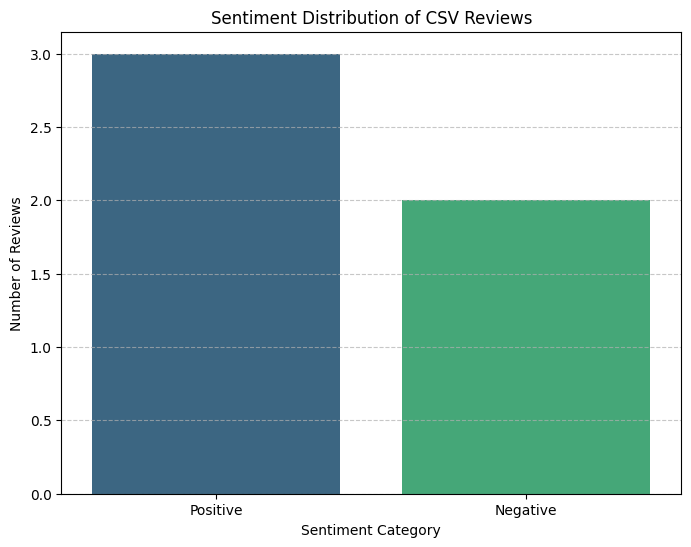

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the occurrences of each sentiment label from the CSV analysis results
csv_sentiment_counts = csv_sentiment_results['sentiment_label'].value_counts().reset_index()
csv_sentiment_counts.columns = ['Sentiment', 'Count']

# Create the bar chart for CSV data
plt.figure(figsize=(8, 6))
sns.barplot(x='Sentiment', y='Count', hue='Sentiment', data=csv_sentiment_counts, palette='viridis', legend=False)
plt.title('Sentiment Distribution of CSV Reviews')
plt.xlabel('Sentiment Category')
plt.ylabel('Number of Reviews')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


This DataFrame provides a clear overview of the sentiment for each text. You can now easily sort, filter, or visualize these results. For example, you could count the number of positive, negative, and neutral sentiments to get an overall idea of the sentiment distribution in a larger dataset.